In [1]:
import os
import json
import gymnasium as gym
import numpy as np
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
SEED = 42
N_ENVS = 8
TOTAL_TIMESTEPS = 20_000_000

LOG_DIR = "./hardcore_3/"
MODEL_DIR = os.path.join(LOG_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ===============================
# HELPERS
# ===============================

class SyncEnvStatsCallback(BaseCallback):
    def __init__(self, eval_env, sync_freq=100_000):
        super().__init__(verbose=0)
        self.eval_env = eval_env
        self.sync_freq = sync_freq

    def _on_step(self) -> bool:
        if self.n_calls % self.sync_freq == 0:
            self.eval_env.obs_rms = self.training_env.obs_rms
        return True

def make_env(rank):
    def _init():
        env = gym.make(ENV_ID)
        env.reset(seed=SEED + rank)
        return env
    return _init

def linear_schedule(initial_value: float, final_value: float = 0.0):
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value + final_value * (1 - progress_remaining)
    return func

l_r = linear_schedule(5e-4, 1e-5)

# ===============================
# ENVIRONMENTS
# ===============================
train_env = SubprocVecEnv([make_env(i) for i in range(N_ENVS)])
train_env = VecNormalize(
    train_env,
    norm_obs=True,
    norm_reward=True,
    gamma=0.995,
    clip_obs=10.0
)

eval_env = SubprocVecEnv([make_env(1000 + i) for i in range(5)])
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False
)

# ===============================
# CALLBACKS
# ===============================

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(MODEL_DIR, "best"),
    log_path=os.path.join(LOG_DIR, "eval"),
    eval_freq=max(100_000 // N_ENVS, 1),
    n_eval_episodes=5,
    deterministic=True,
    verbose=0,
)

sync_stats_callback = SyncEnvStatsCallback(eval_env, 100_000)

# ===============================
# MODEL
# ===============================
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    device=DEVICE,
    seed=SEED,

    # Architecture
    policy_kwargs=dict(
        net_arch=dict(pi=[400, 300], vf=[400, 300]), #next model try [512, 512]
        activation_fn=torch.nn.Tanh,
        ortho_init=True, #i should try Xavier later too
    ),

    # PPO core
    learning_rate=l_r,
    n_steps=2048,
    batch_size=1024,
    n_epochs=8,
    gamma=0.995,    
    gae_lambda=0.95,

    # Stability fixes
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    target_kl=0.02,
    use_sde=True,
    sde_sample_freq=8, #next model try -1

    verbose=0,
)

# ===============================
# TRAIN
# ===============================
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[sync_stats_callback, eval_callback],
    progress_bar=True,
)

# ===============================
# SAVE FINAL
# ===============================
model.save(os.path.join(MODEL_DIR, "final_model"))
train_env.save(os.path.join(MODEL_DIR, "vec_normalize.pkl"))

metadata = {
    "env": ENV_ID,
    "total_timesteps": TOTAL_TIMESTEPS,
    "seed": SEED,
    "n_envs": N_ENVS,
    "device": DEVICE,
}

with open(os.path.join(LOG_DIR, "run_info.json"), "w") as f:
    json.dump(metadata, f, indent=2)

train_env.close()
eval_env.close()

print("✅ Training complete.")


Using device: cpu


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/stable_baselines3/common/evaluation
.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

✅ Training complete.


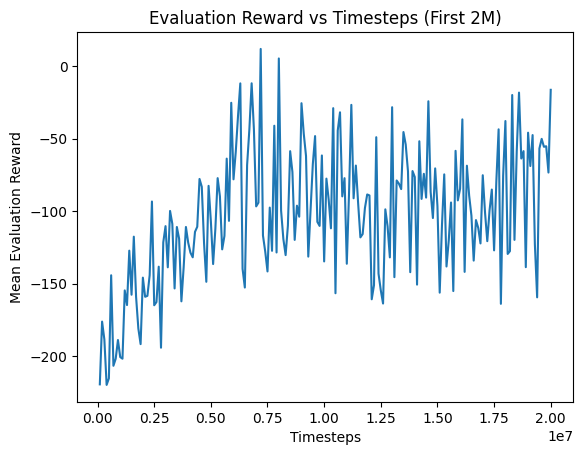

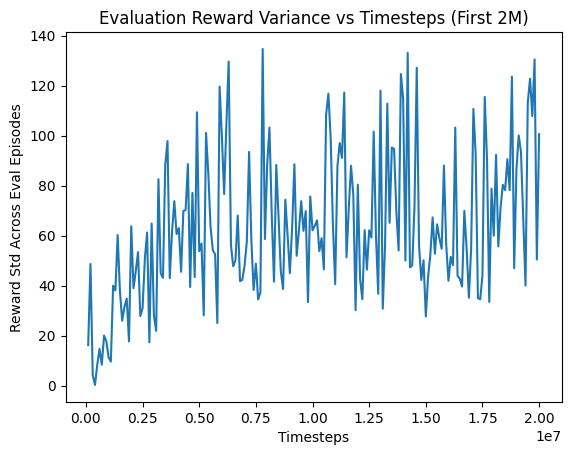

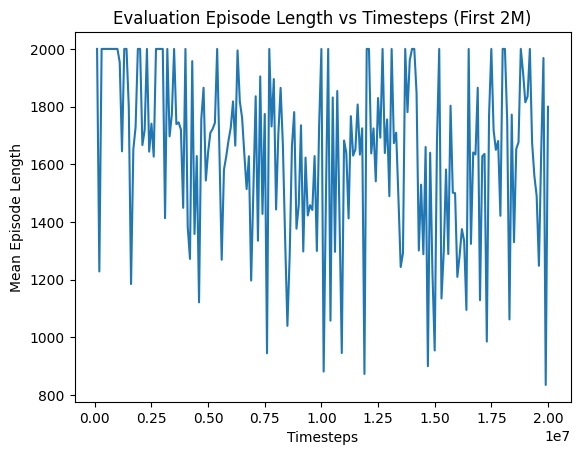

In [3]:
# This script loads Stable-Baselines3 EvalCallback data and plots metrics
# over the first 2,000,000 timesteps.

import numpy as np
import matplotlib.pyplot as plt
import os

LOG_DIR = "./hardcore_3/"
EVAL_DIR = os.path.join(LOG_DIR, "eval")
EVAL_FILE = os.path.join(EVAL_DIR, "evaluations.npz")

assert os.path.exists(EVAL_FILE), "evaluations.npz not found. Make sure EvalCallback ran."

data = np.load(EVAL_FILE)

timesteps = data["timesteps"]
results = data["results"]          # shape: (n_evals, n_episodes)
ep_lengths = data["ep_lengths"]    # shape: (n_evals, n_episodes)


mean_rewards = results.mean(axis=1)
std_rewards = results.std(axis=1)
mean_lengths = ep_lengths.mean(axis=1)

# ===== Plot 1: Mean Eval Reward =====
plt.figure()
plt.plot(timesteps, mean_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Mean Evaluation Reward")
plt.title("Evaluation Reward vs Timesteps (First 2M)")
plt.show()

# ===== Plot 2: Reward Std (Stability) =====
plt.figure()
plt.plot(timesteps, std_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Reward Std Across Eval Episodes")
plt.title("Evaluation Reward Variance vs Timesteps (First 2M)")
plt.show()

# ===== Plot 3: Episode Length =====
plt.figure()
plt.plot(timesteps, mean_lengths)
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Length")
plt.title("Evaluation Episode Length vs Timesteps (First 2M)")
plt.show()


In [1]:
import os
import json
import gymnasium as gym
import numpy as np
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
SEED = 42
N_ENVS = 8
TOTAL_TIMESTEPS = 40_000_000

LOG_DIR = "./hardcore_5/"
MODEL_DIR = os.path.join(LOG_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ===============================
# HELPERS
# ===============================

class SyncEnvStatsCallback(BaseCallback):
    def __init__(self, eval_env, sync_freq=100_000):
        super().__init__(verbose=0)
        self.eval_env = eval_env
        self.sync_freq = sync_freq

    def _on_step(self) -> bool:
        if self.n_calls % self.sync_freq == 0:
            self.eval_env.obs_rms = self.training_env.obs_rms
        return True

def make_env(rank):
    def _init():
        env = gym.make(ENV_ID)
        env.reset(seed=SEED + rank)
        return env
    return _init

def linear_schedule(initial_value: float, final_value: float = 0.0):
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value + final_value * (1 - progress_remaining)
    return func

l_r = linear_schedule(5e-4, 1e-5)

# ===============================
# ENVIRONMENTS
# ===============================
train_env = SubprocVecEnv([make_env(i) for i in range(N_ENVS)])
train_env = VecNormalize(
    train_env,
    norm_obs=True,
    norm_reward=True,
    gamma=0.995,
    clip_obs=10.0
)

eval_env = SubprocVecEnv([make_env(1000 + i) for i in range(5)])
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False
)

# ===============================
# CALLBACKS
# ===============================

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(MODEL_DIR, "best"),
    log_path=os.path.join(LOG_DIR, "eval"),
    eval_freq=max(100_000 // N_ENVS, 1),
    n_eval_episodes=5,
    deterministic=True,
    verbose=0,
)

sync_stats_callback = SyncEnvStatsCallback(eval_env, 100_000)

# ===============================
# MODEL
# ===============================
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    device=DEVICE,
    seed=SEED,

    # Architecture
    policy_kwargs=dict(
        net_arch=dict(pi=[512, 512], vf=[512, 512]), #next model try [512, 512]
        activation_fn=torch.nn.Tanh,
        ortho_init=True, #i should try Xavier later too
    ),

    # PPO core
    learning_rate=l_r,
    n_steps=2048,
    batch_size=1024,
    n_epochs=8,
    gamma=0.995,    
    gae_lambda=0.95,

    # Stability fixes
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    target_kl=0.02,
    use_sde=True,
    sde_sample_freq=8, #next model try -1

    verbose=0,
)

# ===============================
# TRAIN
# ===============================
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[sync_stats_callback, eval_callback],
    progress_bar=True,
)

# ===============================
# SAVE FINAL
# ===============================
model.save(os.path.join(MODEL_DIR, "final_model"))
train_env.save(os.path.join(MODEL_DIR, "vec_normalize.pkl"))

metadata = {
    "env": ENV_ID,
    "total_timesteps": TOTAL_TIMESTEPS,
    "seed": SEED,
    "n_envs": N_ENVS,
    "device": DEVICE,
}

with open(os.path.join(LOG_DIR, "run_info.json"), "w") as f:
    json.dump(metadata, f, indent=2)

train_env.close()
eval_env.close()

print("✅ Training complete.")

Using device: cpu


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

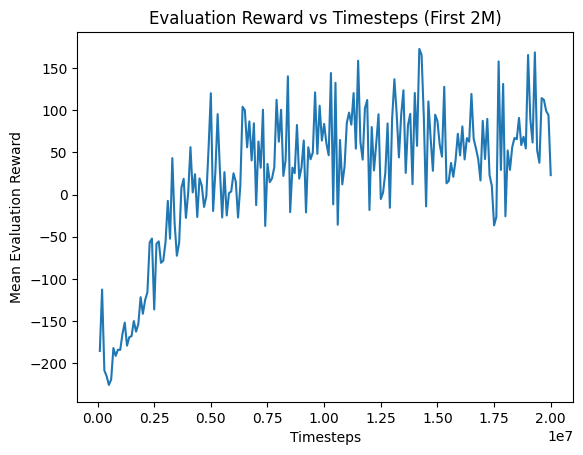

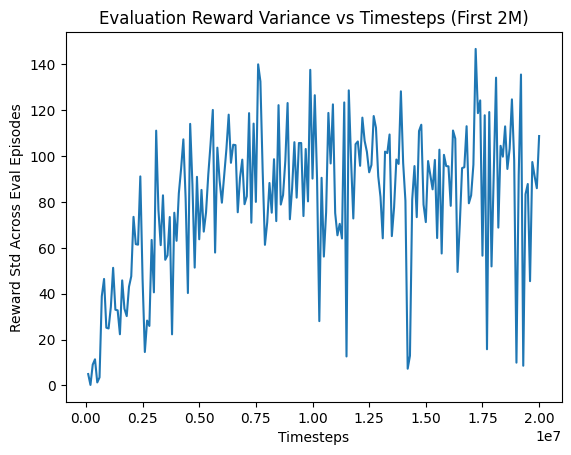

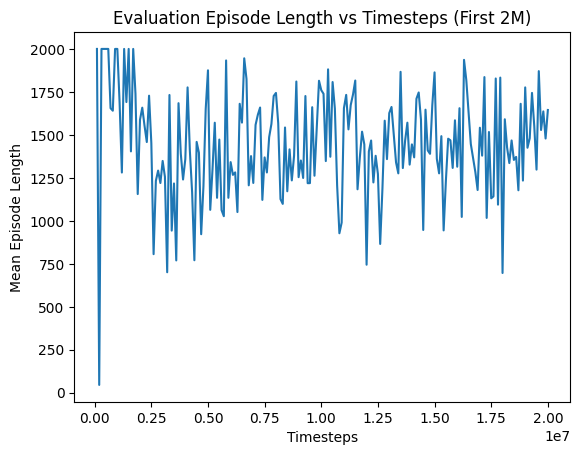

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

LOG_DIR = "./hardcore_5/"
EVAL_DIR = os.path.join(LOG_DIR, "eval")
EVAL_FILE = os.path.join(EVAL_DIR, "evaluations.npz")

assert os.path.exists(EVAL_FILE), "evaluations.npz not found. Make sure EvalCallback ran."

data = np.load(EVAL_FILE)

timesteps = data["timesteps"]
results = data["results"]          # shape: (n_evals, n_episodes)
ep_lengths = data["ep_lengths"]    # shape: (n_evals, n_episodes)


mean_rewards = results.mean(axis=1)
std_rewards = results.std(axis=1)
mean_lengths = ep_lengths.mean(axis=1)

# ===== Plot 1: Mean Eval Reward =====
plt.figure()
plt.plot(timesteps, mean_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Mean Evaluation Reward")
plt.title("Evaluation Reward vs Timesteps")
plt.show()

# ===== Plot 2: Reward Std (Stability) =====
plt.figure()
plt.plot(timesteps, std_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Reward Std Across Eval Episodes")
plt.title("Evaluation Reward Variance vs Timesteps (First 2M)")
plt.show()

# ===== Plot 3: Episode Length =====
plt.figure()
plt.plot(timesteps, mean_lengths)
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Length")
plt.title("Evaluation Episode Length vs Timesteps (First 2M)")
plt.show()
